<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/Tutorial-de-Clustering/blob/main/A3_2_Clustering_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A3.2 – Tutorial de Clustering
**SC3314 – Inteligencia Artificial | Universidad de Monterrey**

Este tutorial cubre dos técnicas fundamentales de aprendizaje no supervisado:
- **Parte 1:** K-Means Clustering
- **Parte 2:** Hierarchical Clustering

El objetivo es que puedas reproducir todos los pasos, entender **qué** se hace, **por qué** se hace, y **qué significan** los resultados.

---
# PARTE 1 – K-Means Clustering

## ¿Qué es el Clustering?

El clustering es un conjunto de técnicas de aprendizaje no supervisado que buscan encontrar **grupos naturales** (clusters) dentro de un conjunto de datos, sin contar con etiquetas previas. La idea central es:
- Las observaciones **dentro del mismo cluster** deben ser muy **similares** entre sí.
- Las observaciones en **clusters distintos** deben ser muy **diferentes**.

**K-Means** es el algoritmo de clustering más popular. Agrupa los datos en *k* grupos minimizando la variación intra-cluster (suma de distancias euclideanas al cuadrado de cada observación a su centroide).

## 1.1 Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

!pip install ISLP
from ISLP import load_data
import seaborn as sns

# Estilo visual consistente
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=682accd9713e086c9ec1313cca32f243cd4fcc84acaebcfd757f0a31f1148a67
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


---
## 1.2 Dataset Sintético con `make_blobs`

Para entender el algoritmo desde cero, comenzamos con un dataset **sintético y controlado**. La función `make_blobs` genera datos con grupos bien definidos, lo que nos permite visualizar claramente cómo K-Means va convergiendo.

Usaremos:
- **1000 muestras**, **3 centros** y **2 variables** → podemos graficar en 2D fácilmente.
- `cluster_std=1.5` → los grupos tendrán algo de traslape, haciendo el problema más realista.

> **Importante:** ocultamos las etiquetas verdaderas en la primera gráfica para simular el escenario real de clustering, donde no conocemos los grupos de antemano.

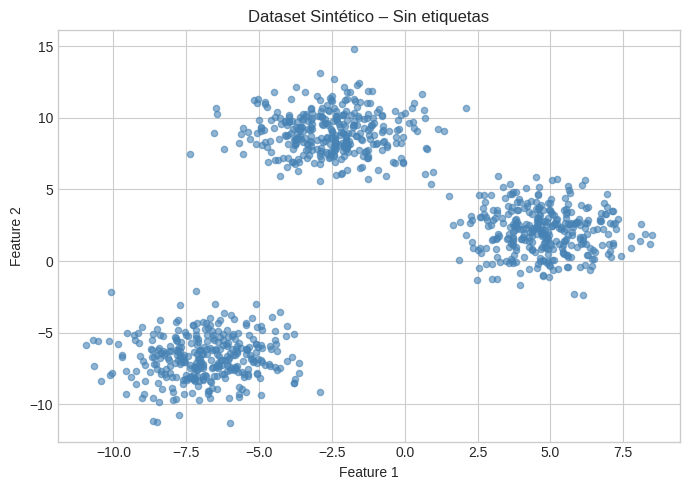

In [3]:
# Crear dataset sintético
X, y_true = make_blobs(n_samples=1000, centers=3, n_features=2,
                       cluster_std=1.5, random_state=RANDOM_SEED)

# Graficar sin etiquetas (escenario real: no conocemos los grupos)
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6, color='steelblue')
plt.title('Dataset Sintético – Sin etiquetas')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

---
## 1.3 Paso 1 – Asignación Aleatoria Inicial

K-Means comienza asignando **aleatoriamente** cada observación a uno de los *k* clusters. Esta asignación inicial es solo un punto de partida; el algoritmo la irá refinando iterativamente.

Usamos una **semilla aleatoria** (`random_state`) para reproducibilidad.

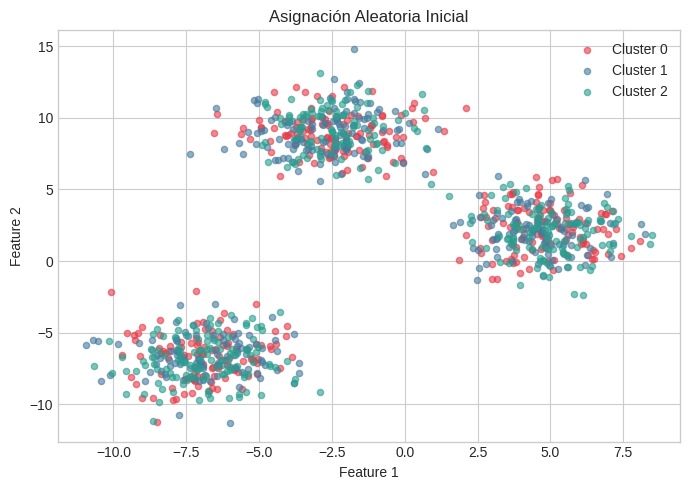

Distribución inicial (aleatoria): [334 330 336]


In [4]:
rng = np.random.default_rng(seed=RANDOM_SEED)
labels = rng.integers(0, 3, size=len(X))  # asignar aleatoriamente a cluster 0, 1 o 2

colors_map = ['#E63946', '#457B9D', '#2A9D8F']

plt.figure(figsize=(7, 5))
for k in range(3):
    mask = labels == k
    plt.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.6,
                color=colors_map[k], label=f'Cluster {k}')
plt.title('Asignación Aleatoria Inicial')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

print('Distribución inicial (aleatoria):', np.bincount(labels))

---
## 1.4 Paso 2 – Cálculo de Centroides

El **centroide** de un cluster es el vector que contiene la **media de cada variable** para todas las observaciones de ese cluster. Geométricamente, es el "centro de masa" del grupo.

En esta primera iteración, los centroides reflejan la asignación aleatoria, por lo que no representan bien los grupos reales.

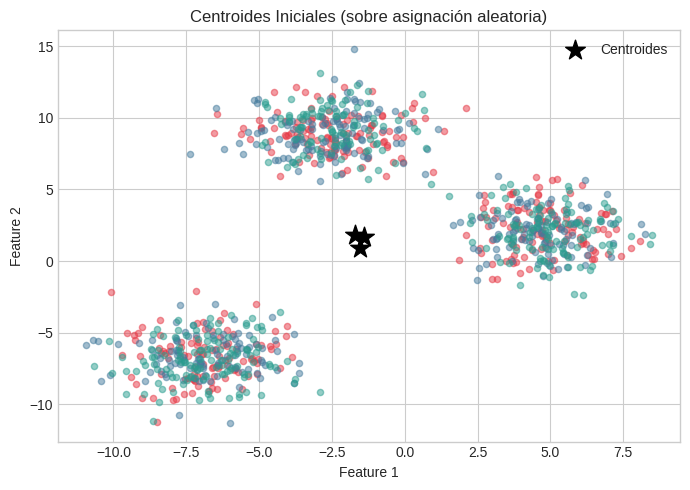

Centroides iniciales:
  Cluster 0: [-1.38109341  1.66137641]
  Cluster 1: [-1.69211634  1.79934994]
  Cluster 2: [-1.55015653  0.92697581]


In [5]:
def compute_centroids(X, labels, k):
    """Calcula el centroide de cada cluster como la media de sus observaciones."""
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

centroids = compute_centroids(X, labels, k=3)

plt.figure(figsize=(7, 5))
for k in range(3):
    mask = labels == k
    plt.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.5, color=colors_map[k])
plt.scatter(centroids[:, 0], centroids[:, 1], s=220, marker='*',
            c='black', zorder=5, label='Centroides')
plt.title('Centroides Iniciales (sobre asignación aleatoria)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

print('Centroides iniciales:')
for i, c in enumerate(centroids):
    print(f'  Cluster {i}: {c}')

---
## 1.5 Paso 3 – Iteración: Re-asignación y Actualización de Centroides

El corazón del algoritmo K-Means es un ciclo de dos pasos que se repite hasta que las asignaciones no cambien:

1. **Re-asignar:** Cada observación se asigna al cluster cuyo centroide esté más cercano (**distancia euclideana**).
2. **Actualizar:** Se recalculan los centroides con la nueva asignación.

Este código está diseñado para **actualizar las etiquetas en el mismo arreglo** (sin crear datasets nuevos), lo que refleja cómo funciona realmente el algoritmo.

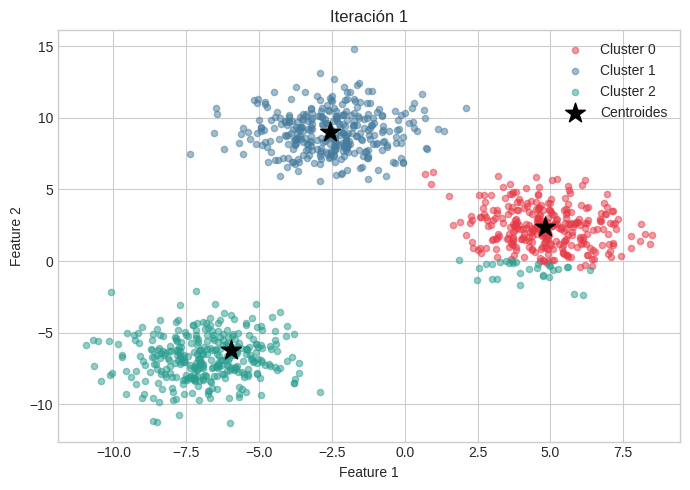

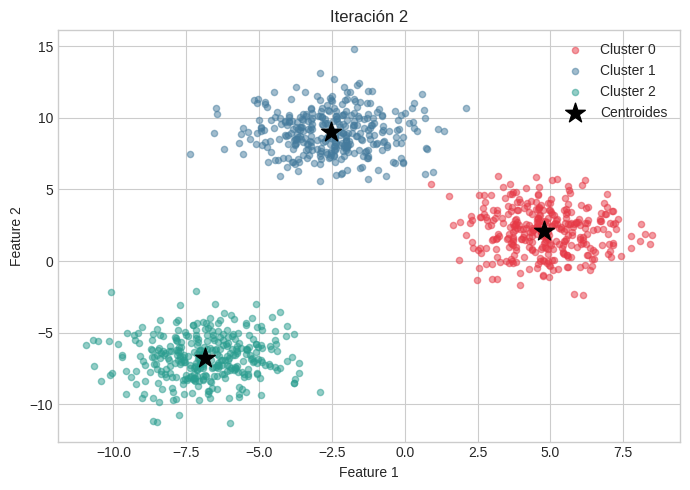

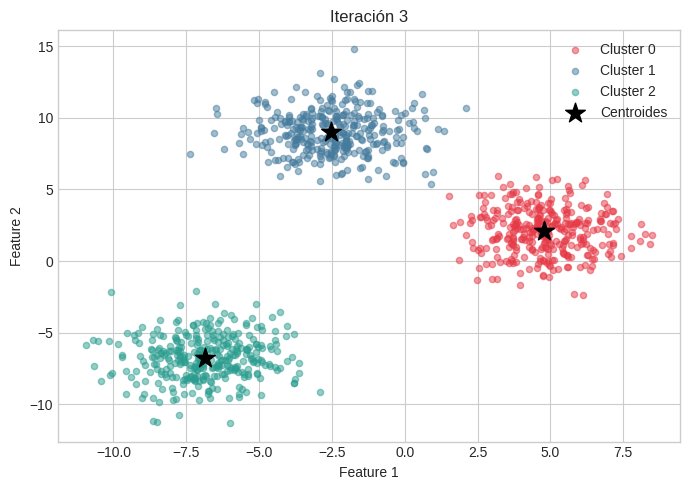

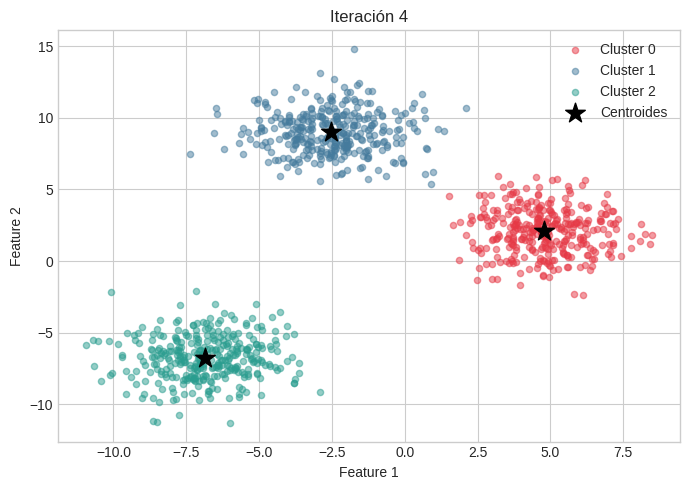

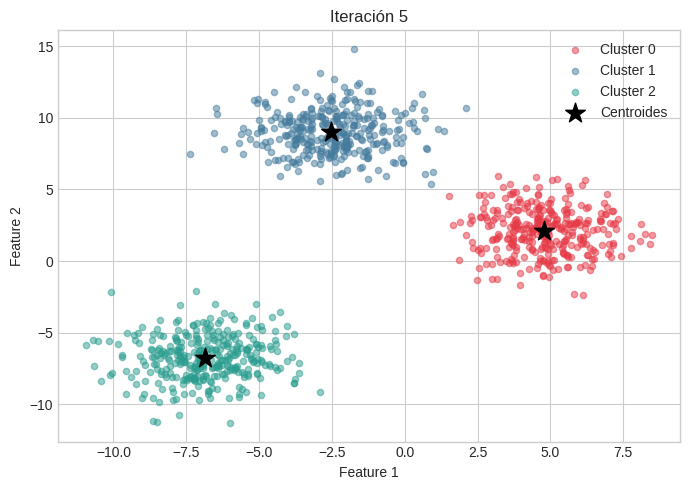

In [6]:
def assign_labels(X, centroids):
    """Asigna cada punto al centroide más cercano (distancia euclideana)."""
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # shape (n, k)
    return np.argmin(distances, axis=1)

def plot_clusters(X, labels, centroids, title):
    plt.figure(figsize=(7, 5))
    for k in range(len(centroids)):
        mask = labels == k
        plt.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.5, color=colors_map[k],
                    label=f'Cluster {k}')
    plt.scatter(centroids[:, 0], centroids[:, 1], s=220, marker='*',
                c='black', zorder=5, label='Centroides')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Iteración manual (5 pasos)
for iteration in range(1, 6):
    labels = assign_labels(X, centroids)   # re-asignar
    centroids = compute_centroids(X, labels, k=3)  # actualizar centroides
    plot_clusters(X, labels, centroids, f'Iteración {iteration}')

**Interpretación:** Observa cómo en las primeras iteraciones los centroides se desplazan rápidamente hacia el centro de los grupos naturales y los colores van tomando forma. Después de pocas iteraciones el algoritmo **converge** y las asignaciones ya no cambian.

---
## 1.6 Estocasticidad de K-Means

Dado que K-Means parte de una asignación aleatoria, puede quedar atrapado en un **óptimo local** diferente dependiendo del punto de partida. Esto se llama **estocasticidad**.

Para demostrar esto, corremos el proceso varias veces **sin semilla fija** y observamos los resultados.

> **Solución estándar:** correr el algoritmo múltiples veces (`n_init`) y quedarse con la solución que tenga la **menor variación intra-cluster** (menor objetivo = better fit).

/tmp/ipykernel_1133/2753630598.py:3: RuntimeWarning: Mean of empty slice.
  return np.array([X[labels == i].mean(axis=0) for i in range(k)])
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


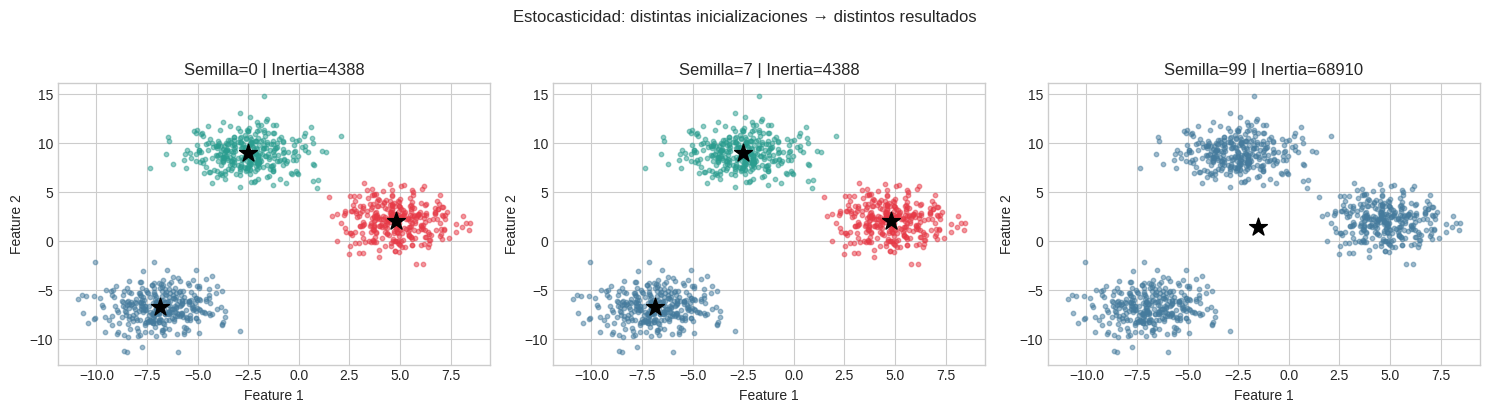

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, seed in enumerate([0, 7, 99]):
    # Sin semilla fija → resultados potencialmente distintos
    rng_s = np.random.default_rng(seed=seed)
    lbl = rng_s.integers(0, 3, size=len(X))
    cents = compute_centroids(X, lbl, 3)
    for _ in range(20):
        lbl = assign_labels(X, cents)
        cents = compute_centroids(X, lbl, 3)

    inertia = sum(np.sum((X[lbl == k] - cents[k])**2) for k in range(3))
    for k in range(3):
        mask = lbl == k
        axes[ax_idx].scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.5, color=colors_map[k])
    axes[ax_idx].scatter(cents[:, 0], cents[:, 1], s=180, marker='*', c='black', zorder=5)
    axes[ax_idx].set_title(f'Semilla={seed} | Inertia={inertia:.0f}')
    axes[ax_idx].set_xlabel('Feature 1')
    axes[ax_idx].set_ylabel('Feature 2')

plt.suptitle('Estocasticidad: distintas inicializaciones → distintos resultados', y=1.02)
plt.tight_layout()
plt.show()

---
## 1.7 Dataset Real: NCI60

Ahora aplicamos K-Means a un dataset real de expresión génica. **NCI60** contiene datos de 64 líneas celulares de cáncer con mediciones de expresión para miles de genes. El objetivo es descubrir si las líneas celulares se agrupan de forma coherente con su tipo de cáncer.

Este es un problema de alta dimensionalidad (muchas variables), por lo que aplicar clustering directamente puede no ser óptimo → usaremos **PCA** como preprocesamiento.

### 1.7.1 Importar y explorar el dataset

In [10]:
# Cargar NCI60
nci60 = load_data('NCI60')
X_nci = nci60['data']   # matriz de expresión génica
y_nci = nci60['labels'] # tipo de cáncer (labels)

print('Shape del dataset:', X_nci.shape)
print('\nDistribución de tipos de cáncer:')
print(y_nci['label'].value_counts())

Shape del dataset: (64, 6830)

Distribución de tipos de cáncer:
label
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


**Interpretación:** Tenemos 64 muestras y miles de genes (variables). Con esta dimensionalidad, visualizar directamente o calcular distancias euclideanas pierde significado → hay que reducir dimensiones con PCA.

### 1.7.2 K-Means directo (sin PCA)

Primero probamos K-Means con los datos crudos, usando entre 3 y 5 clusters y `n_init=50` para mitigar la estocasticidad.

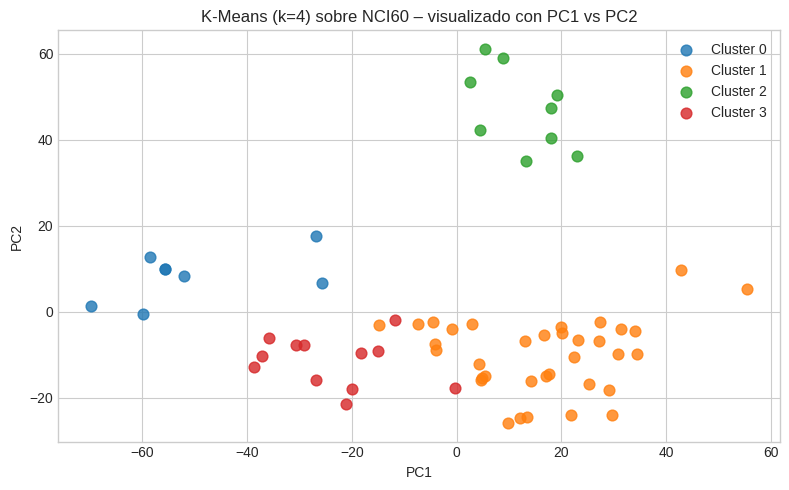

In [11]:
# Estandarizar datos antes de clustering (buena práctica)
scaler = StandardScaler()
X_nci_scaled = scaler.fit_transform(X_nci)

km4 = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_SEED)
km4.fit(X_nci_scaled)
labels_km4 = km4.labels_

# Visualizar con primeras dos variables de PCA (solo para graficar)
pca_viz = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca_viz.fit_transform(X_nci_scaled)

plt.figure(figsize=(8, 5))
for c in np.unique(labels_km4):
    mask = labels_km4 == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=60, alpha=0.8, label=f'Cluster {c}')
plt.title('K-Means (k=4) sobre NCI60 – visualizado con PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

---
## 1.8 Preprocesamiento con PCA

**¿Por qué PCA antes de K-Means?**
- Con miles de genes, la **maldición de la dimensionalidad** hace que las distancias euclideanas pierdan significado.
- PCA transforma los datos a un espacio de menor dimensión donde la **varianza máxima** está capturada.
- El clustering en el espacio PCA tiende a ser más robusto y significativo.

Primero graficamos la **varianza explicada acumulada** para elegir cuántos componentes conservar.

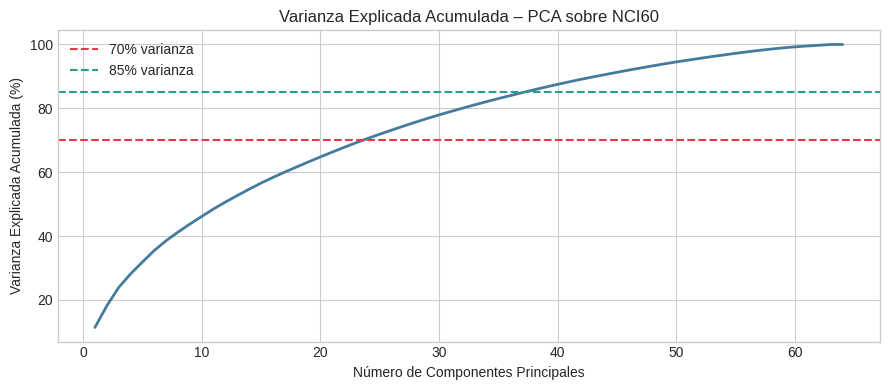

PCs para 70% varianza: 24
PCs para 85% varianza: 38


In [12]:
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_nci_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='#457B9D', linewidth=2)
plt.axhline(70, color='#E63946', linestyle='--', label='70% varianza')
plt.axhline(85, color='#2A9D8F', linestyle='--', label='85% varianza')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada (%)')
plt.title('Varianza Explicada Acumulada – PCA sobre NCI60')
plt.legend()
plt.tight_layout()
plt.show()

# Cuántos PCs para llegar al 70% y 85%
print(f'PCs para 70% varianza: {np.searchsorted(cumvar, 70) + 1}')
print(f'PCs para 85% varianza: {np.searchsorted(cumvar, 85) + 1}')

**Interpretación:** El codo de la curva nos indica el punto donde agregar más componentes aporta poco. Seleccionamos el número de PCs que captura al menos ~70-85% de la varianza total como balance entre reducción de ruido y retención de información.

Componentes seleccionados: 24


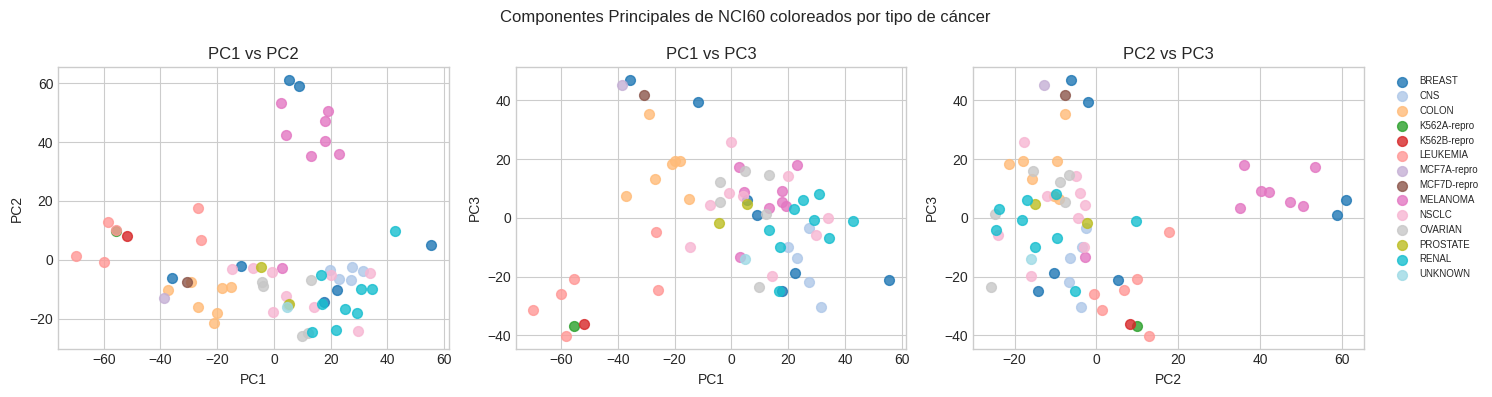

In [15]:
# Selección: PCs hasta ~70% de varianza explicada
N_COMPONENTS = np.searchsorted(cumvar, 70) + 1
print(f'Componentes seleccionados: {N_COMPONENTS}')

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_nci_scaled)

# Graficar pares de PCs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [(0, 1), (0, 2), (1, 2)]
cancer_types = np.array(y_nci['label']) # Fix: Access the 'label' column to get a 1D array
unique_types = np.unique(cancer_types)
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))

for ax, (i, j) in zip(axes, pairs):
    for idx, ct in enumerate(unique_types):
        mask = cancer_types == ct
        ax.scatter(X_pca[mask, i], X_pca[mask, j], s=50,
                   color=palette[idx], label=ct, alpha=0.8)
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('Componentes Principales de NCI60 coloreados por tipo de cáncer')
plt.tight_layout()
plt.show()

---
## 1.9 K-Means con PCA

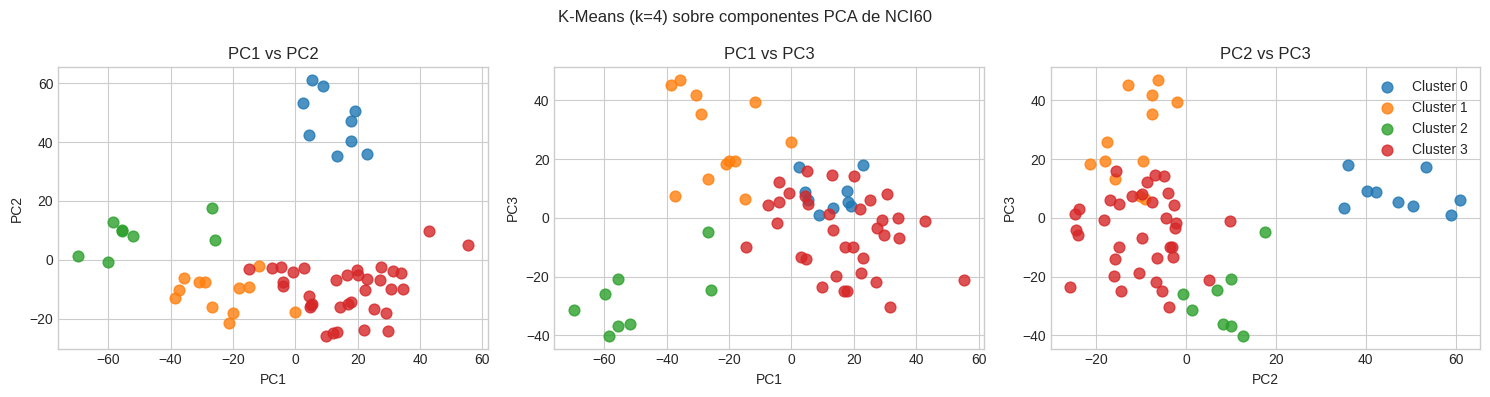

In [16]:
km_pca = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_SEED)
km_pca.fit(X_pca)
labels_pca = km_pca.labels_

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (i, j) in zip(axes, pairs):
    for c in np.unique(labels_pca):
        mask = labels_pca == c
        ax.scatter(X_pca[mask, i], X_pca[mask, j], s=60, alpha=0.8, label=f'Cluster {c}')
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')
axes[2].legend()
plt.suptitle('K-Means (k=4) sobre componentes PCA de NCI60')
plt.tight_layout()
plt.show()

---
## 1.10 Interpretación de los Clusters

### Tabla de Clases vs Clusters

Esta tabla muestra cuántas muestras de cada **tipo de cáncer** caen en cada **cluster**. Si el clustering es bueno, esperamos que cada cluster esté dominado por uno o pocos tipos de cáncer.

In [17]:
df_interp = pd.DataFrame({'Cancer': cancer_types, 'Cluster': labels_pca})
tabla = pd.crosstab(df_interp['Cancer'], df_interp['Cluster'])
print(tabla)

Cluster      0  1  2  3
Cancer                 
BREAST       2  2  0  3
CNS          0  0  0  5
COLON        0  7  0  0
K562A-repro  0  0  1  0
K562B-repro  0  0  1  0
LEUKEMIA     0  0  6  0
MCF7A-repro  0  1  0  0
MCF7D-repro  0  1  0  0
MELANOMA     7  0  0  1
NSCLC        0  1  0  8
OVARIAN      0  0  0  6
PROSTATE     0  0  0  2
RENAL        0  0  0  9
UNKNOWN      0  0  0  1


### Heatmap de Genes Más Relevantes

Para entender **qué genes** distinguen a los clusters, seleccionamos los genes con mayor diferencia de expresión entre dos clusters elegidos. Esto permite identificar marcadores biológicos asociados a cada grupo.

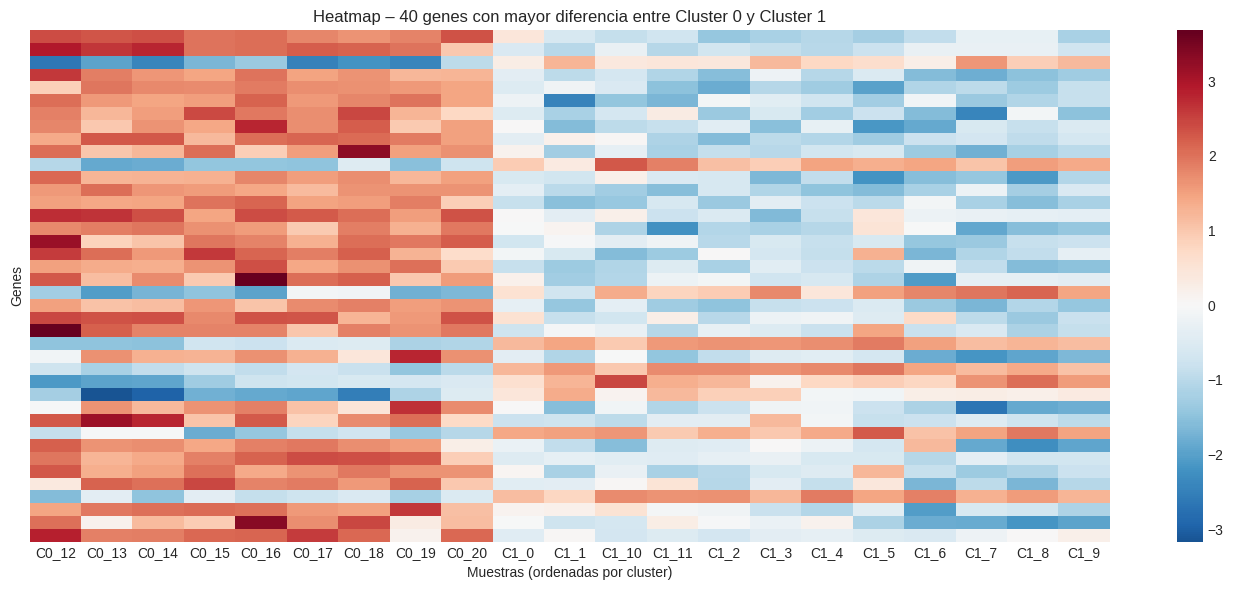

In [18]:
# Seleccionar clusters 0 y 1 para comparar
X_nci_df = pd.DataFrame(X_nci_scaled)
X_nci_df['Cluster'] = labels_pca

c0 = X_nci_df[X_nci_df['Cluster'] == 0].drop(columns='Cluster')
c1 = X_nci_df[X_nci_df['Cluster'] == 1].drop(columns='Cluster')

mean_diff = (c0.mean() - c1.mean()).abs()
top_genes = mean_diff.nlargest(40).index

heatmap_data = X_nci_df[X_nci_df['Cluster'].isin([0, 1])].copy()
heatmap_genes = heatmap_data[top_genes].copy()
heatmap_genes.index = [f'C{c}_{i}' for i, c in
                        enumerate(heatmap_data['Cluster'].values)]
heatmap_genes = heatmap_genes.sort_index()

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_genes.T, cmap='RdBu_r', center=0,
            xticklabels=True, yticklabels=False, linewidths=0)
plt.title('Heatmap – 40 genes con mayor diferencia entre Cluster 0 y Cluster 1')
plt.xlabel('Muestras (ordenadas por cluster)')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

**Interpretación del Heatmap:** Los colores rojizos indican alta expresión y los azules baja expresión. Si los clusters son biológicamente significativos, deberían verse bloques de color claramente diferenciados entre las muestras de cada cluster para los genes seleccionados.

---
---
# PARTE 2 – Hierarchical Clustering

## ¿Qué es el Hierarchical Clustering?

A diferencia de K-Means, el clustering jerárquico **no requiere especificar k de antemano**. En cambio, genera una estructura de árbol completa llamada **dendograma** que representa todos los posibles agrupamientos, desde 1 cluster (todas las observaciones juntas) hasta n clusters (cada observación sola).

La estrategia **aglomerativa** (bottom-up) comienza con cada observación como su propio cluster y va fusionando los más similares progresivamente.

## 2.1 Importaciones adicionales

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

## 2.2 Cargar NCI60 y Preprocesamiento con PCA

Reutilizamos el mismo dataset NCI60 ya estandarizado. Antes del clustering jerárquico, aplicamos PCA para determinar el número adecuado de componentes y reducir ruido.

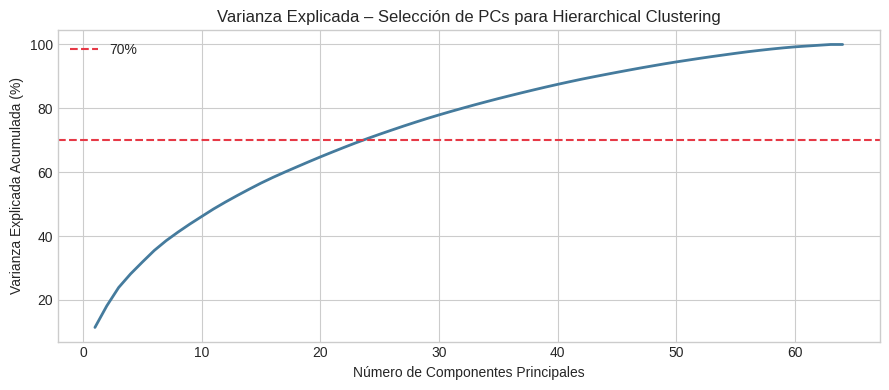

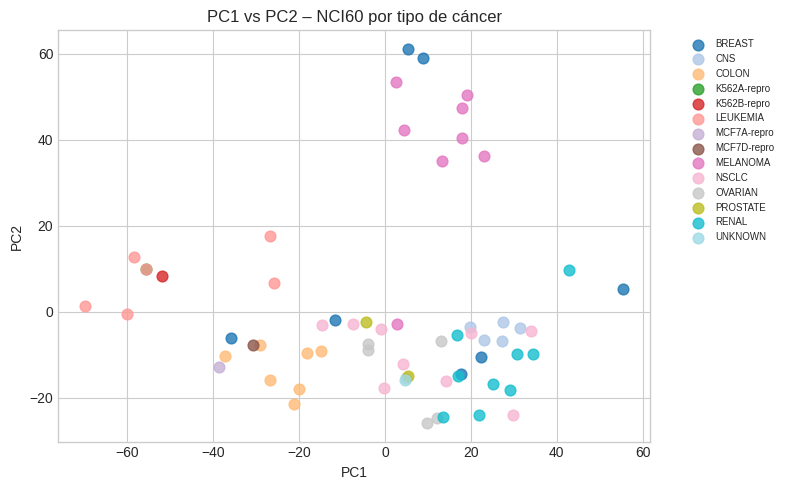

In [20]:
# X_nci_scaled y X_pca ya están calculados de la Parte 1
# Si corres esta sección de forma independiente, ejecuta las celdas de carga y PCA de la Parte 1 primero.

# Graficar varianza explicada nuevamente para referencia
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='#457B9D', linewidth=2)
plt.axhline(70, color='#E63946', linestyle='--', label='70%')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada (%)')
plt.title('Varianza Explicada – Selección de PCs para Hierarchical Clustering')
plt.legend()
plt.tight_layout()
plt.show()

# PC1 vs PC2 con etiquetas reales
plt.figure(figsize=(8, 5))
for idx, ct in enumerate(unique_types):
    mask = cancer_types == ct
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=60,
                color=palette[idx], label=ct, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 – NCI60 por tipo de cáncer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

---
## 2.3 Hierarchical Clustering – Complete Linkage + Euclidean

Comenzamos con la configuración más común:
- **Método:** `complete` linkage → la disimilitud entre dos grupos se define como la distancia máxima entre cualquier par de observaciones (una de cada grupo). Tiende a generar clusters compactos y balanceados.
- **Métrica:** `euclidean` → distancia euclideana estándar.

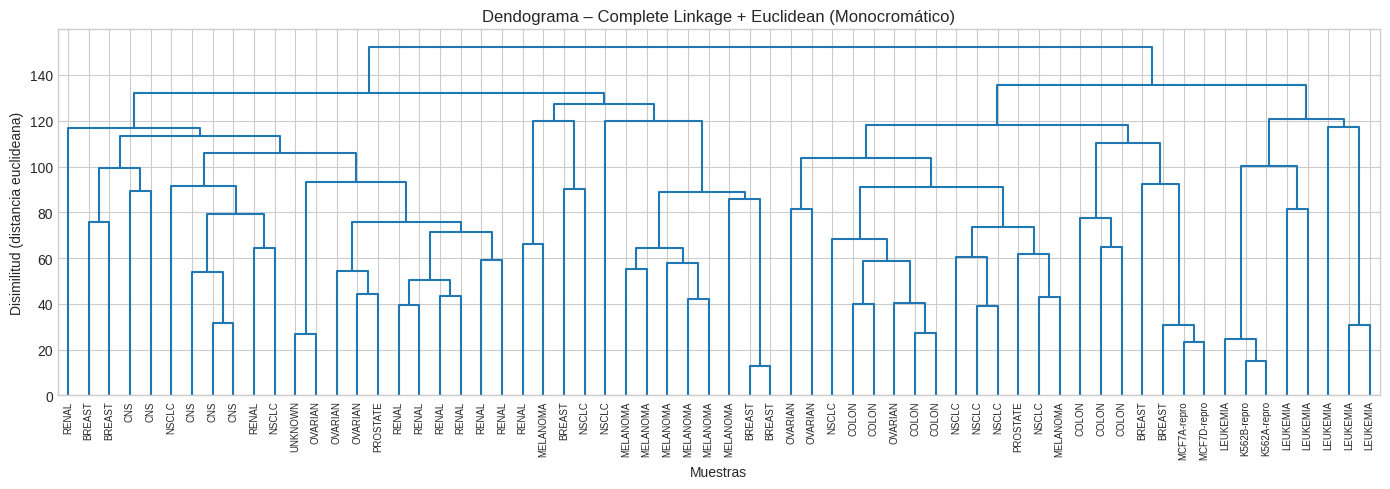

In [21]:
# Calcular la matriz de linkage
Z_complete_euc = linkage(X_pca, method='complete', metric='euclidean')

# Dendograma monocromático
plt.figure(figsize=(14, 5))
dendrogram(Z_complete_euc, labels=list(cancer_types),
           leaf_rotation=90, leaf_font_size=7, color_threshold=0)
plt.title('Dendograma – Complete Linkage + Euclidean (Monocromático)')
plt.xlabel('Muestras')
plt.ylabel('Disimilitud (distancia euclideana)')
plt.tight_layout()
plt.show()

**¿Cómo leer el dendograma?**
- Cada **hoja** del árbol es una observación (línea celular).
- Las hojas se unen en **ramas** que representan clusters.
- Las uniones más **bajas** (menor eje Y) indican observaciones muy similares.
- El **eje Y** representa la disimilitud en el momento de la fusión.
- Cortar el árbol horizontalmente a una altura dada produce un número específico de clusters.

---
## 2.4 Dendograma Policromático – Diferentes Cortes

Ajustamos el `color_threshold` para visualizar cómo distintos cortes del árbol producen 2, 3 o 4 clusters.

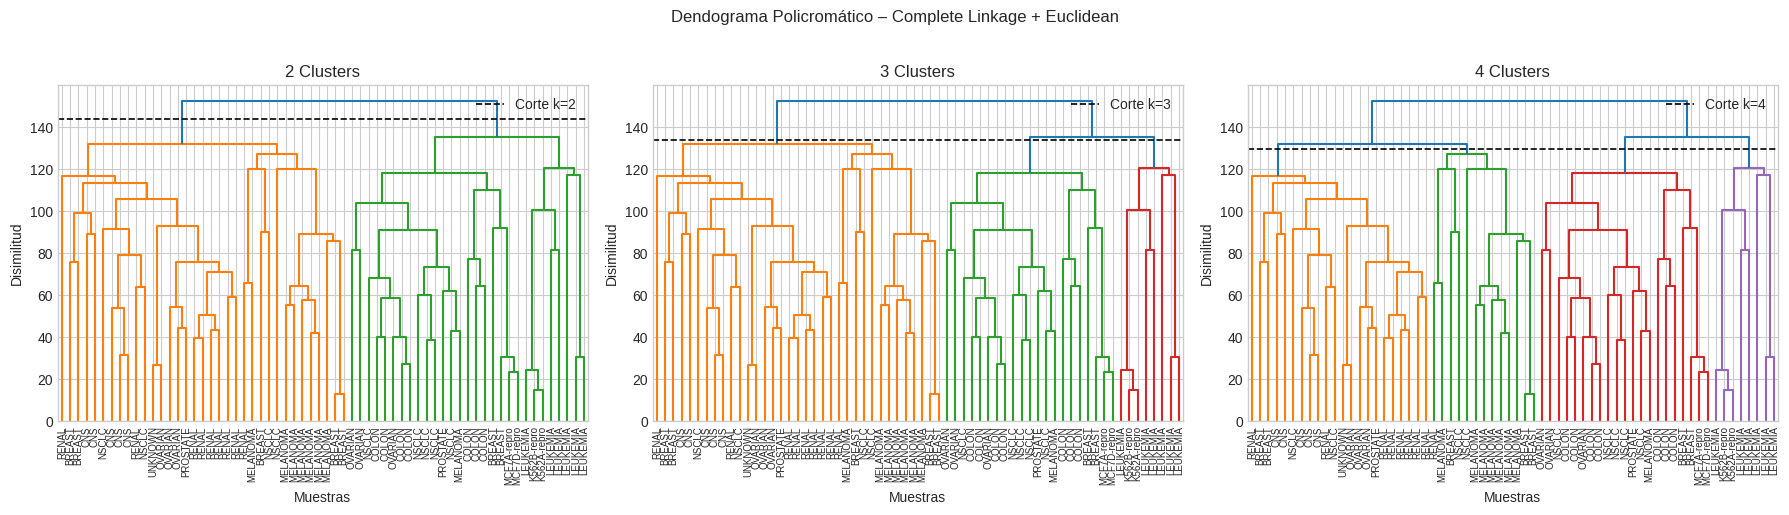

In [22]:
# Obtener las alturas de fusión para determinar thresholds
heights = Z_complete_euc[:, 2]

def get_threshold_for_k(Z, k):
    """Devuelve el threshold de color que produce aproximadamente k clusters."""
    # Las últimas k-1 fusiones producen k clusters al cortarlas
    sorted_heights = np.sort(Z[:, 2])[::-1]
    return (sorted_heights[k-2] + sorted_heights[k-1]) / 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [2, 3, 4]):
    thresh = get_threshold_for_k(Z_complete_euc, k)
    plt.sca(ax)
    dendrogram(Z_complete_euc, labels=list(cancer_types),
               leaf_rotation=90, leaf_font_size=7,
               color_threshold=thresh, ax=ax)
    ax.axhline(thresh, color='black', linestyle='--', linewidth=1.2, label=f'Corte k={k}')
    ax.set_title(f'{k} Clusters')
    ax.set_xlabel('Muestras')
    ax.set_ylabel('Disimilitud')
    ax.legend()

plt.suptitle('Dendograma Policromático – Complete Linkage + Euclidean', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** La línea punteada muestra el corte. Los colores representan los diferentes clusters en ese nivel. Nota que al aumentar k, los clusters del nivel anterior se **subdividen** (por eso se llama jerárquico: los clusters están anidados).

> **Ventaja sobre K-Means:** No necesitamos pre-especificar k. El dendograma nos lo sugiere visualmente buscando un "gap" grande en el eje Y (un salto grande en disimilitud indica que dos clusters muy distintos están siendo fusionados).

---
## 2.5 Efecto de la Métrica: Euclidean vs Correlation

La **métrica de disimilitud** define *qué significa* que dos observaciones sean similares:

| Métrica | Pregunta que responde | Ejemplo de uso |
|---|---|---|
| **Euclidean** | ¿Qué tan lejos están los vectores? Importan los valores absolutos | Volumen de compras |
| **Correlation** | ¿Qué tan similares son los patrones? No importan los valores, sino la forma | Preferencias de compra |

En biología, la **correlación** suele ser más relevante porque dos genes pueden estar igual de "activos" aunque uno tenga expresión 10x mayor si ambos siguen el mismo patrón entre muestras.

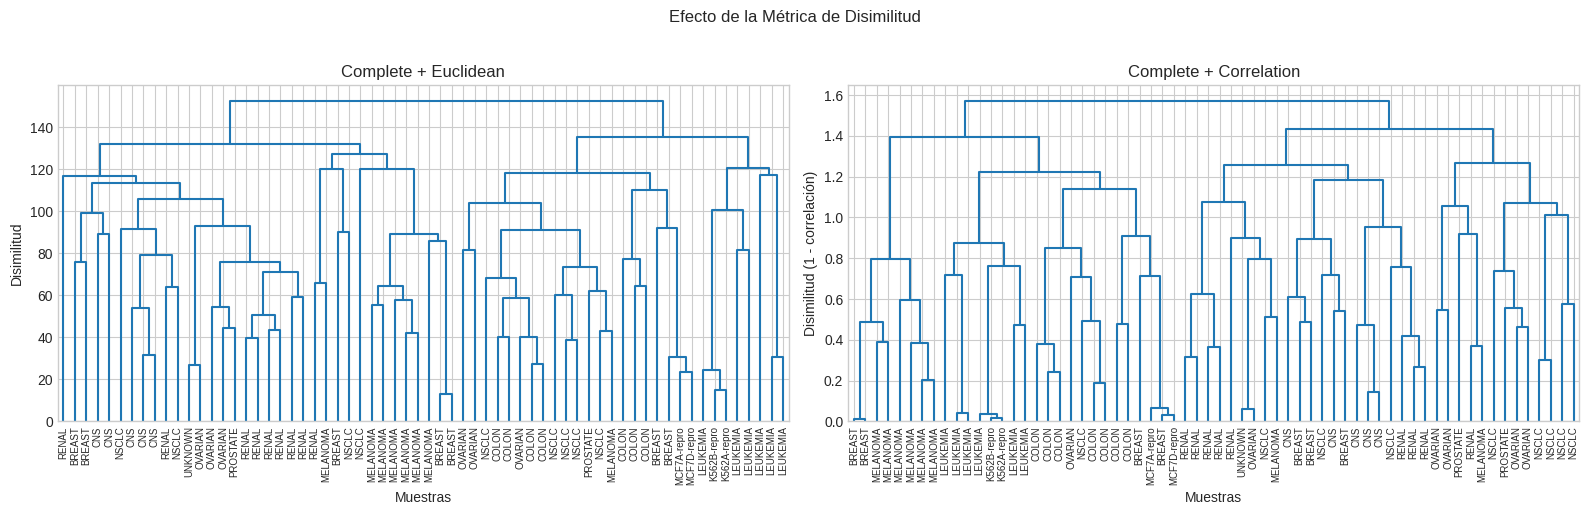

In [23]:
# Hierarchical clustering con correlación como métrica
# Nota: scipy requiere convertir correlación en distancia (1 - |correlation|)
corr_dist = pdist(X_pca, metric='correlation')
Z_complete_corr = linkage(corr_dist, method='complete')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Euclidean
plt.sca(axes[0])
dendrogram(Z_complete_euc, labels=list(cancer_types),
           leaf_rotation=90, leaf_font_size=7, color_threshold=0, ax=axes[0])
axes[0].set_title('Complete + Euclidean')
axes[0].set_xlabel('Muestras')
axes[0].set_ylabel('Disimilitud')

# Correlation
plt.sca(axes[1])
dendrogram(Z_complete_corr, labels=list(cancer_types),
           leaf_rotation=90, leaf_font_size=7, color_threshold=0, ax=axes[1])
axes[1].set_title('Complete + Correlation')
axes[1].set_xlabel('Muestras')
axes[1].set_ylabel('Disimilitud (1 - correlación)')

plt.suptitle('Efecto de la Métrica de Disimilitud', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Observa cómo la estructura del árbol cambia sustancialmente. Con la métrica de correlación, muestras que expresan genes de forma proporcional se agrupan juntas, aunque sus niveles absolutos de expresión sean distintos.

---
## 2.6 Efecto del Método de Linkage: Average vs Complete

El **método de linkage** define cómo se mide la disimilitud entre dos **grupos** (no solo entre dos puntos):

| Método | Definición | Efecto |
|---|---|---|
| **Complete** | Distancia máxima entre pares | Clusters compactos, balanceados |
| **Single** | Distancia mínima entre pares | Clusters elongados, sensible a ruido |
| **Average** | Promedio de todas las distancias | Punto medio, menos extremo |
| **Ward** | Minimiza incremento en varianza intra-cluster | Clusters del tamaño más similar |

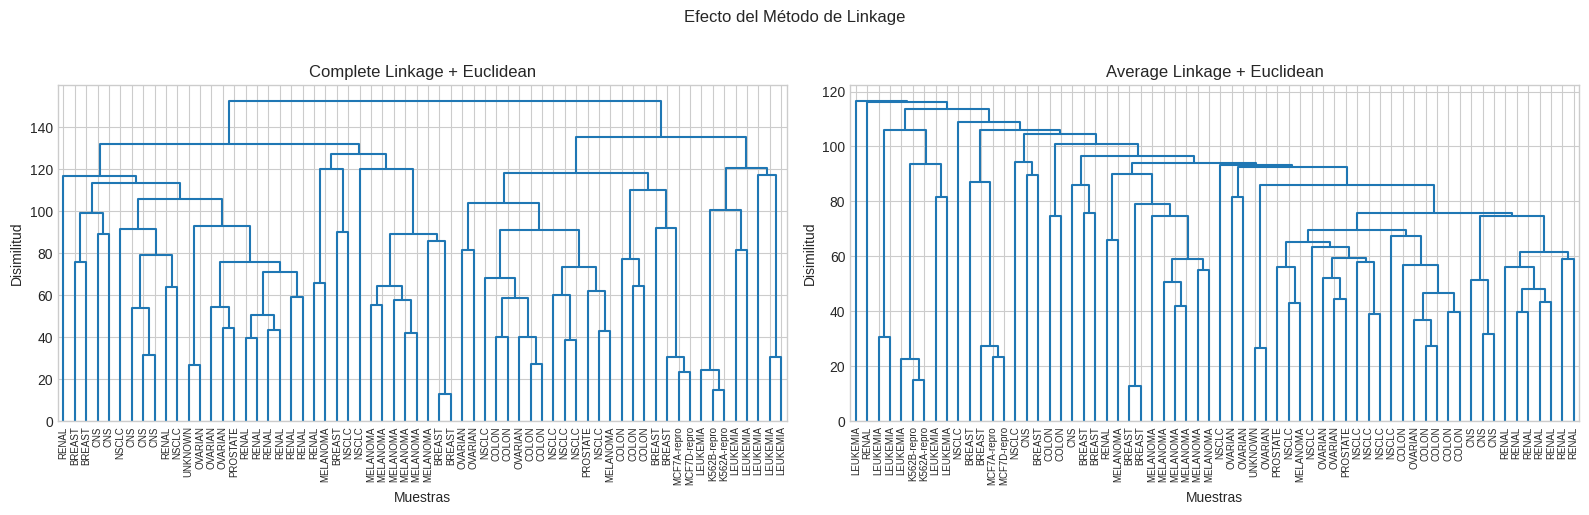

In [24]:
Z_average_euc = linkage(X_pca, method='average', metric='euclidean')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
dendrogram(Z_complete_euc, labels=list(cancer_types),
           leaf_rotation=90, leaf_font_size=7, color_threshold=0, ax=axes[0])
axes[0].set_title('Complete Linkage + Euclidean')
axes[0].set_xlabel('Muestras')
axes[0].set_ylabel('Disimilitud')

plt.sca(axes[1])
dendrogram(Z_average_euc, labels=list(cancer_types),
           leaf_rotation=90, leaf_font_size=7, color_threshold=0, ax=axes[1])
axes[1].set_title('Average Linkage + Euclidean')
axes[1].set_xlabel('Muestras')
axes[1].set_ylabel('Disimilitud')

plt.suptitle('Efecto del Método de Linkage', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** El método **complete** tiende a producir dendogramas más simétricos con clusters de tamaño parecido. El método **average** puede producir estructuras más asimétricas. La elección del método de linkage puede cambiar qué observaciones quedan agrupadas.

**Conclusión práctica:** No hay una elección universalmente correcta. Lo más importante es entender qué pregunta estás respondiendo y seleccionar métrica y linkage acordes al problema.

---
## 2.7 Resumen Comparativo: K-Means vs Hierarchical Clustering

| Aspecto | K-Means | Hierarchical |
|---|---|---|
| **Número de clusters** | Debe especificarse antes | Se elige después (del dendograma) |
| **Estructura** | Plana | Jerárquica (anidada) |
| **Escalabilidad** | Alta (eficiente con datos grandes) | Baja (O(n²) o O(n² log n)) |
| **Reproducibilidad** | Estocástico (necesita n_init) | Determinístico |
| **Flexibilidad de métrica** | Principalmente Euclidean | Cualquier métrica de disimilitud |
| **Interpretación** | Centroides interpretables | Dendograma revela estructura completa |
| **Limitación principal** | Óptimo local, clusters esféricos | No corregible: una fusión mala es permanente |